# Naive Keyword Matching

This notebook builds and evaluates a deliberately naive baseline: for each job, every CV is scored by **how many of the job's keywords appear in the CV's skills**, and CVs are ranked from highest to lowest count. The goal is to establish a floor that later approaches (e.g. an LLM-as-judge) must beat, and to document honestly where keyword matching fails.

Input: `data/resume_clean.pkl`, produced by `01_eda.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_pickle("../data/resume_clean.pkl")
print(df.shape)

(9544, 35)


In [2]:
df["matched_words"] = [cv & job for cv, job in zip(df["cv_keywords"], df["job_keywords"])]
df["match_count"] = df["matched_words"].map(len)

count    9544.000000
mean        1.872171
std         2.038970
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        19.000000
Name: match_count, dtype: float64
Share of pairs with zero matches: 0.31


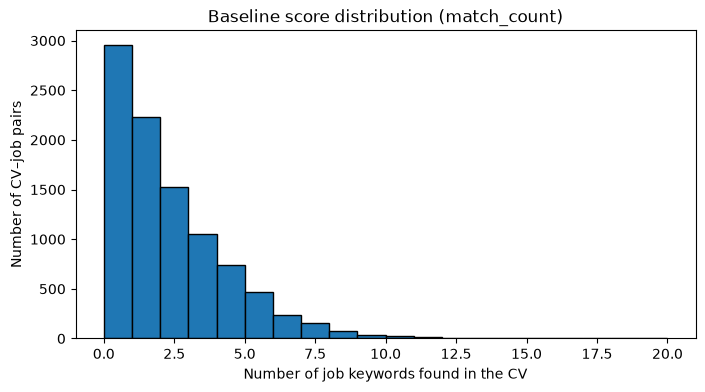

In [3]:
print(df["match_count"].describe())
print("Share of pairs with zero matches:", (df["match_count"] == 0).mean().round(3))

plt.figure(figsize=(8, 4))
plt.hist(df["match_count"], bins=range(0, 21), edgecolor="black")
plt.xlabel("Number of job keywords found in the CV")
plt.ylabel("Number of CV–job pairs")
plt.title("Baseline score distribution (match_count)")
plt.show()

In [4]:
df["baseline_rank"] = (df.groupby("job_position_name")["match_count"]
                         .rank(ascending=False, method="min"))

df[df["job_position_name"] == "Executive - VAT"].sort_values("baseline_rank")[
    ["baseline_rank", "match_count", "matched_words", "positions", "matched_score"]].head(5)

,baseline_rank,match_count,matched_words,positions,matched_score
1290,1.0,7,"{forms, documentation, management, software, o...","['Staff Accountant', 'Financial Aid Accounting...",0.816667
7500,1.0,7,"{maintenance, ms, management, software, coordi...","['Accountant', 'District Administrative Manage...",0.716667
4897,1.0,7,"{ms, management, tasks, software, office, tax,...","['Accountant', 'Tax Accountant', 'Accounting M...",0.926667
5872,1.0,7,"{maintenance, ms, management, coordination, of...","['Lead Accountant', 'Senior Accountant', 'Seni...",0.816667
3472,5.0,6,"{liaison, forms, documentation, management, co...","['Business Development & Marketing', 'Corporat...",0.850000


In [5]:
def tie_stats(group):
    counts = group["match_count"]
    return pd.Series({
        "distinct_scores": counts.nunique(),
        "max_match": counts.max(),
        "zero_match_%": round((counts == 0).mean() * 100, 1),
        "tied_at_10th": (counts == counts.nlargest(10).iloc[-1]).sum(),
    })

ties = df.groupby("job_position_name").apply(tie_stats, include_groups=False)
ties.sort_values("distinct_scores")

,distinct_scores,max_match,zero_match_%,tied_at_10th
job_position_name,,,,
Head of Internal Control & Compliance (ICC) - SEVP/DMD,6.0,5.0,62.2,12.0
Mechanical Engineer,6.0,5.0,72.4,6.0
Sr.Officer / Executive - Internal Audit,6.0,6.0,43.4,13.0
Business Development Executive,7.0,6.0,43.4,10.0
Manager- Human Resource Management (HRM),7.0,6.0,46.6,11.0
Mechanical Designer,7.0,6.0,54.3,8.0
"Executive/ Senior Executive- Trade Marketing, Hygiene Products",7.0,8.0,43.4,12.0
DevOps Engineer,7.0,6.0,25.6,14.0
Marketing Officer,7.0,9.0,37.8,9.0


In [6]:
from scipy.stats import spearmanr

df["n_cv_keywords"] = df["cv_keywords"].map(len)
corr = spearmanr(df["n_cv_keywords"], df["match_count"]).correlation
print("Spearman (CV keyword count vs match count):", round(corr, 3))

Spearman (CV keyword count vs match count): 0.48


### How the baseline behaves

**Scores are very low and coarse.** The median CV matches just **1** job keyword (mean 1.87, max 19), and **31% of all CV–job pairs match zero keywords**. Scores are small whole numbers, so each job's ~341 CVs are squeezed into only **6 to 17 distinct scores**.

**Ties are heavy.** For most jobs, several CVs share 10th place (up to **23 CVs for ML Engineer**, 15 for the Generative AI Intern, 14 for DevOps). The baseline's "top 10" is therefore partly arbitrary. For some jobs most applicants score zero (**72% for Mechanical Engineer**, 62% for Head of ICC), so the baseline cannot distinguish between them at all.

**It sometimes looks sensible.** For Executive – VAT, the top 5 CVs are all accountants (matched_score 0.72–0.93). The baseline clearly picks up genuine domain signal when a job's vocabulary is distinctive (`ledger`, `tax`).

**But for partly the wrong reasons.** Most of those accountants' matched words are generic: `management`, `office`, `software`, `ms`, `tasks`, `coordination`. None of the top 5 actually matched `vat` or `mushak`, the most job-specific words.

**Length bias.** CVs that list more skills match more keywords (Spearman **0.48** between a CV's keyword count and its match count). A candidate with a long, padded skills list is rewarded regardless of fit. This is exactly the weakness keyword stuffing exploits.

In [7]:
BUSINESS_JOBS = [
    "HR Officer",
    "Manager- Human Resource Management (HRM)",
    "Executive - VAT",
    "Sr.Officer / Executive - Internal Audit",
    "Head of Internal Control & Compliance (ICC) - SEVP/DMD",
    "Business Development Executive",
    "Marketing Officer",
    "Asst. Manager/ Manger (Administrative)",
]
print(all(job in df["job_position_name"].unique() for job in BUSINESS_JOBS))


True


In [8]:
from scipy.stats import spearmanr

def evaluate(group):
    cutoff = group["matched_score"].nlargest(10).iloc[-1]
    baseline_top10 = group.nlargest(10, "match_count")
    return pd.Series({
        "spearman": spearmanr(group["match_count"], group["matched_score"]).correlation,
        "precision_at_10": (baseline_top10["matched_score"] >= cutoff).mean(),
        "random_precision": (group["matched_score"] >= cutoff).mean(),
    })

In [9]:
results = df.groupby("job_position_name").apply(evaluate, include_groups=False)
results["business"] = results.index.isin(BUSINESS_JOBS)

print(results.round(3).sort_values("spearman"))
print("\nAll 28 jobs:\n", results[["spearman", "precision_at_10", "random_precision"]].mean().round(3))
print("\nBy slice:\n", results.groupby("business")[["spearman", "precision_at_10", "random_precision"]].mean().round(3))
print("\nJobs with positive Spearman:", (results["spearman"] > 0).sum(), "of 28")

                                                    spearman  precision_at_10  \
job_position_name                                                               
Senior Software Engineer                              -0.018              0.3   
Data Science Engineer                                  0.030              0.0   
Database Administrator (DBA)                           0.076              0.2   
Network Support Engineer                               0.135              0.7   
Data Engineer                                          0.142              0.2   
DevOps Engineer                                        0.173              0.3   
Executive/ Sr. Executive -IT                           0.179              0.6   
Marketing Officer                                      0.197              0.1   
Intern (Generative AI Engineering - 2D/3D Image...     0.212              0.5   
Senior iOS Engineer                                    0.217              0.3   
Project Coordinator (Civil) 

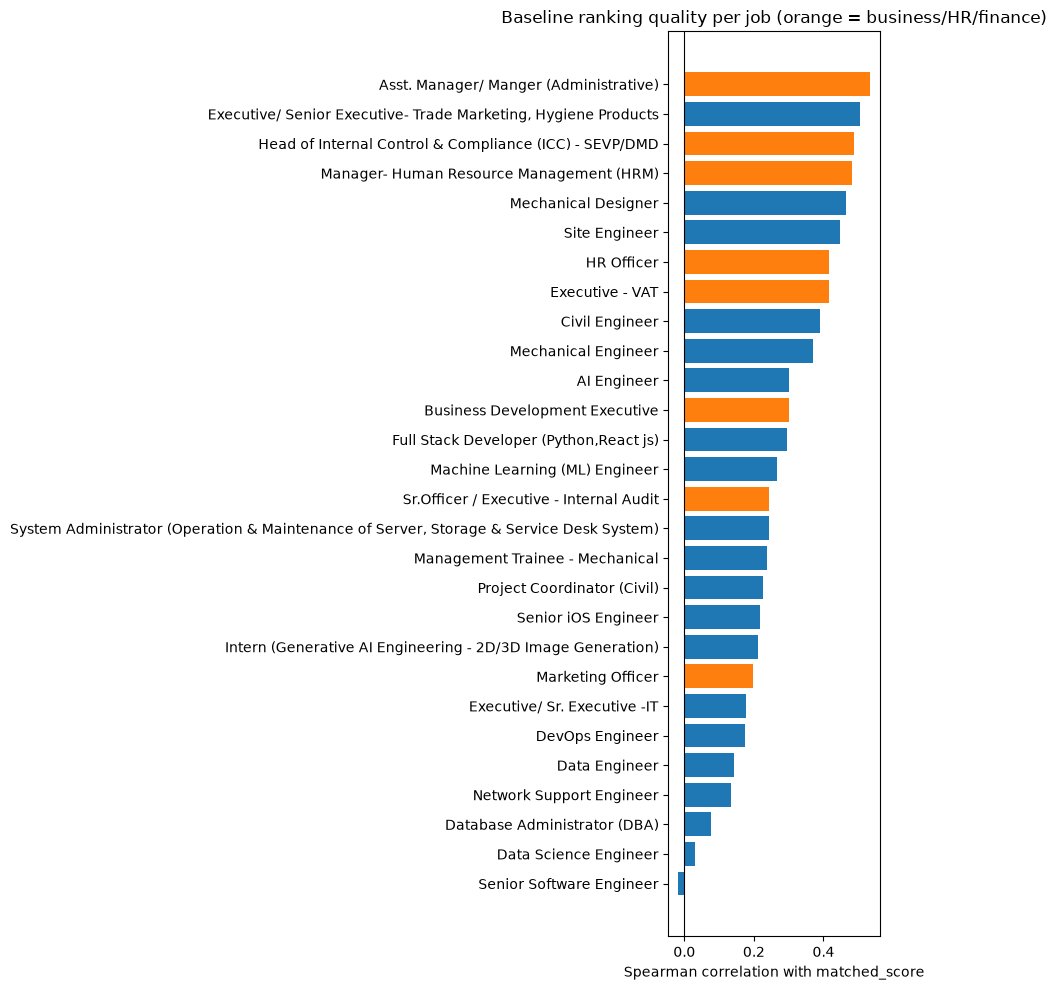

In [10]:
plot_data = results.sort_values("spearman")
colors = ["tab:orange" if b else "tab:blue" for b in plot_data["business"]]

plt.figure(figsize=(9, 10))
plt.barh(plot_data.index, plot_data["spearman"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Spearman correlation with matched_score")
plt.title("Baseline ranking quality per job (orange = business/HR/finance)")
plt.tight_layout()
plt.show()

### Evaluation results

The baseline was evaluated **within each job** against `matched_score` using two metrics:
- **Spearman correlation:** how similar the baseline's full ranking of ~341 CVs is to `matched_score` (1 = identical order, 0 = unrelated).
- **Precision@10 (tie-aware):** the share of the baseline's top 10 CVs that are truly top candidates, i.e. score at least the 10th-best `matched_score`. This counts all CVs tied at 10th place as top, because `matched_score` itself has heavy ties (a median of 34 CVs share the 10th-best score).

Each is compared with **random ranking**: the precision expected if 10 CVs were picked at random.

| | Spearman | Precision@10 | Random precision@10 |
|---|---|---|---|
| **All 28 jobs** | **0.285** | **0.33** | 0.125 |
| **Business/HR/finance slice (8 jobs)** | **0.385** | **0.35** | 0.093 |
| Other jobs (20) | 0.244 | 0.32 | 0.138 |

**What this shows:**
- **The baseline beats random, but weakly.** Spearman is positive for 27 of 28 jobs, and precision@10 is about **2.6× random** overall. On average, about 3 of the baseline's top 10 are genuinely top candidates, and **7 are not**.
- **It works best on the Cytonn-like jobs.** The business slice has the highest correlation (0.385) and the biggest gain over random (about **3.8×**). These jobs use distinctive vocabulary (`ledger`, `tax`, `audit`, `recruitment`). Best: Admin Manager (0.535), Head of ICC (0.487), HRM Manager (0.482).
- **It fails on technical jobs with generic wording.** Senior Software Engineer (−0.018), Data Science Engineer (0.030) and Database Administrator (0.076) are no better than random. Their keywords (`data`, `software`, `system`) appear on almost every technical CV, so they cannot separate candidates.
- **Precision@10 is inflated where `matched_score` has huge ties.** For example, 116 CVs are "truly top" for the Generative AI Intern, so almost any pick counts as a hit. Spearman is the more reliable of the two metrics here.

**This is the floor:** Spearman ≈ **0.29** overall and ≈ **0.39** on the business slice, with precision@10 ≈ **0.33**. Any later approach must clearly beat these numbers.